In [1]:
import os, sys
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"

GMFLOW = os.path.join("submodules", "GMFlow")
sys.path.insert(0, GMFLOW)

In [2]:
from backbones.gmdit import GMDiT

# 사용 예
model = GMDiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv-full`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '
2025-09-18 18:14:48.910302: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/logpx_samplers/submodules/GMFlow/lib/ops/gmflow_ops/gmflow_ops.py:31: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

cannot get type annotation for Parameter scheduler of <class 'lib.pipelines.gmdit_pipeline.GMDiTPipeline'>.


Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

Expected types for id2label: (typing.Dict[int, str], <class 'NoneType'>), got typing.Dict[str, str].


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import math

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1, 3):  # CHW -> HWC
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if n == 0:
        return

    # 6x3 그리드 설정
    ncols, nrows = 9, 3
    per_page = ncols * nrows
    num_pages = math.ceil(n / per_page)

    for page in range(num_pages):
        start = page * per_page
        end = min(start + per_page, n)
        count = end - start

        fig_w = ncols * figsize_per_image
        fig_h = nrows * figsize_per_image
        fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=30)
        axes = np.atleast_2d(axes)

        plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

        if display_title:
            title_text = f"{display_title}  ({page+1}/{num_pages})" if num_pages > 1 else display_title
            fig.text(0.5, 0.995, title_text, ha='center', va='top', fontsize=10)

        for i in range(nrows * ncols):
            r, c = divmod(i, ncols)
            ax = axes[r, c]
            if i < count:
                img_arr = processed[start + i]
                ax.imshow(img_arr)
            ax.set_axis_off()

        plt.margins(0, 0)
        plt.show()


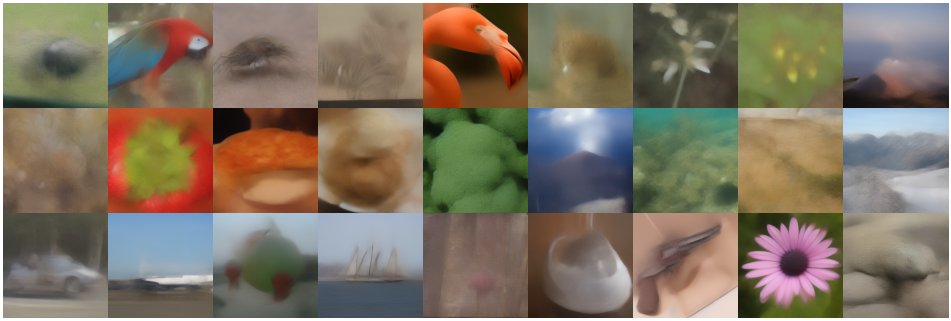

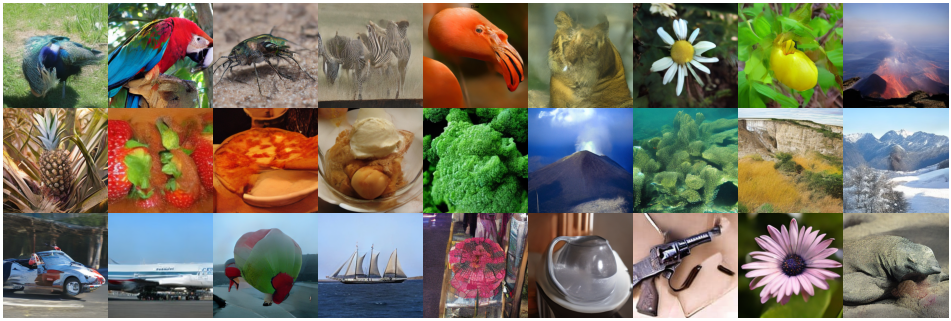

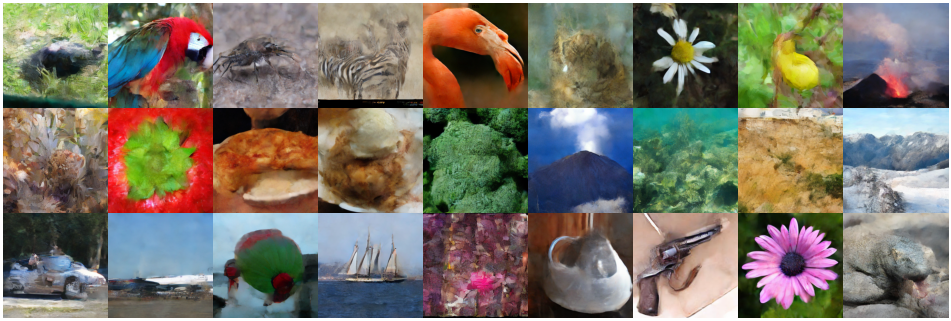

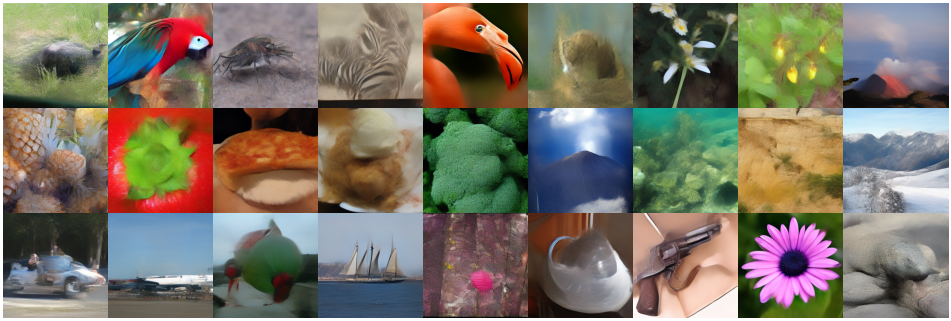

In [4]:
import numpy as np
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver
from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
from utils.util import get_pt
import torch
from solvers.competing.bns.bns_solver import BNS_Solver
from solvers.competing.ds.ds_solver_flow import DS_Solver


imagenet_indices = [
    84, 88, 300, 340, 130, 292,
    985, 986, 980, 953, 949, 963,
    928, 937, 980, 973, 972, 970,
    817, 404, 417, 780, 879, 899,
    763, 985, 48, 89, 322, 394,
]

class_ids = imagenet_indices[:27]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=1.5)
noises = model.get_noise(seeds=[i+1 for i in range(len(class_ids))])

NFE = 3

solver = DPM_Solver(noise_schedule, algorithm_type="data_prediction", steps=NFE, skip_type="time_uniform_flow", flow_shift=3.0)
dpm_latents = solver.sample(noises, model_fn)['samples']
dpm_samples = model.decode_vae(dpm_latents, pil_output=True)['pil_output']
display_class_images(dpm_samples, class_ids, display_title='DPM')

extractor = Extractor(steps=NFE)
transform = LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2)
solver = GDual_Solver(
    noise_schedule,
    steps=NFE,
    transform=transform,
    param_extractor=extractor,
    skip_type="time_uniform_flow",
    flow_shift=3.0,
    pred_order=1,
    corr_order=2,
    order1_kappa=True,
    order2_kappa=True,
    use_corrector=True,
    time_learning=True,
    train_mode=True
).to(model.device)
pt_file = get_pt(f'logs/gmdit/mobile/s{NFE}', 'latest')
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, pil_output=True)['pil_output']
display_class_images(samples, class_ids, display_title='Dual')


solver = BNS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=3.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

pt_file = get_pt(f'logs/gmdit/bns/s{NFE}/', label='latest')
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, pil_output=True)['pil_output']
display_class_images(samples, class_ids, display_title='BNS')

solver = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=3.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

pt_file = get_pt(f'logs/gmdit/ds/s{NFE}/', label='latest')
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, pil_output=True)['pil_output']
display_class_images(samples, class_ids, display_title='DS')